In [1]:
import numpy as np
import openmdao.api as om
import dymos as dm
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
import xarray as xr

#from dymos.examples.oscillator.oscillator_ode import OscillatorODE


In [2]:
def td_to_fd(td, fft=True, zero_freq=True):
    """Convert a real array of time-domain responses to a complex array
    of Fourier coefficients."""

    td = np.atleast_1d(td)
    td = np.expand_dims(td, -1) if len(td.shape)==1 else td

    n = td.shape[0]
    if fft:
        fd = np.fft.rfft(td, n=n, axis=0, norm='forward')
    else:
        fd = np.dot(dft(n, 'n')[:n//2+1, :], td)
    fd = np.concatenate((fd[:1, :], fd[1:-1, :]*2, fd[-1:, :]))
    if not zero_freq:
        fd = fd[1:, :]
    return fd

def mimo_transfer_mat(transfer_mat,zero_freq = False):
    """Create a block matrix of the MIMO transfer function."""

    ndof = 1 #transfer_mat.shape[1]
    #assert transfer_mat.shape[2] == ndof
    elem = [[None]*ndof for _ in range(ndof)]
    def block(re, im): return np.array([[re, -im], [im, re]])
    for idof in range(ndof):
        for jdof in range(ndof):
            if zero_freq:
                Zp0 = transfer_mat[0]
                assert np.all(np.isreal(Zp0))
                Zp0 = np.real(Zp0)
                Zp = transfer_mat[1:]
            else:
                Zp0 = [0.0]
                Zp = transfer_mat[:]
            re = np.real(Zp)
            im = np.imag(Zp)
            blocks = [block(ire, iim) for (ire, iim) in zip(re[:-1], im[:-1])]
            blocks = [Zp0] + blocks + [re[-1]]
            elem[idof][jdof] = block_diag(*blocks)
    return np.block(elem)

def complex_to_real(fd, zero_freq = True):
    """Convert from one complex amplitude to two real amplitudes per
    frequency.    """

    fd = np.atleast_1d(fd)
    fd = np.expand_dims(fd, -1) if len(fd.shape)==1 else fd

    nfreq = fd.shape[0] - 1 if zero_freq else fd.shape[0]
    ndof = fd.shape[1]
    if zero_freq:
        #assert jnp.all(jnp.isreal(fd[0, :]))
        a = np.real(fd[0:1, :])
        b = np.real(fd[1:-1, :])
        c = np.imag(fd[1:-1, :])
        d = np.real(fd[-1:, :])
    else:
        b = np.real(fd[:-1, :])
        c = np.imag(fd[:-1, :])
        d = np.real(fd[-1:, :])
    out = np.concatenate([np.transpose(b), np.transpose(c)])
    out = np.reshape(np.reshape(out, [-1], order='F'), [-1, ndof])
    if zero_freq:
        out = np.concatenate([a, out, d])
        #assert out.shape == (2*nfreq, ndof)
    else:
        out = np.concatenate([out, d])
        #assert out.shape == (2*nfreq-1, ndof)
    return out

def time_func(f1, nfreq, nsubsteps = 1):
    """Assemble the time vector with :python:`nsubsteps` subdivisions.    """
    if nsubsteps < 1:
        raise ValueError("'nsubsteps' must be 1 or greater")
    nsteps = nsubsteps * 2 * nfreq
    return np.linspace(0, 1/f1, nsteps, endpoint=False)

def time_mat_func(f1, nfreq, nsubsteps = 1, zero_freq = True):
    """Assemble the time matrix that converts the state to a
    time-series.    """

    t = time_func(f1, nfreq, nsubsteps)
    omega = np.arange(0, nfreq+1)* f1 * 2*np.pi
    wt = np.outer(t, omega[1:])
    ncomp = 2*nfreq
    time_mat = np.empty((nsubsteps*ncomp, ncomp))
    
    time_mat[:, 0] = 1.0
    time_mat[:, 1::2] = np.cos(wt)
    time_mat[:, 2::2] = -np.sin(wt[:, :-1]) # remove 2pt wave sine component
    if not zero_freq:
        time_mat = time_mat[:, 1:]
    return time_mat


In [3]:
wavefreq = 0.1 # Hz
f1 = wavefreq
nfreq = 10
t_interp = np.linspace(0, 1/f1, 2*nfreq, endpoint=False)
t_interp_full = np.linspace(0, 1/f1, 2*nfreq+1, endpoint=True)

bem_data = xr.open_dataset('bem_wb_10.nc')

In [4]:
class OscillatorODE(om.ExplicitComponent):
    """
    A Dymos ODE for a damped harmonic oscillator.
    """

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        nf = nfreq
        ar = np.arange(nn)

        # Inputs
        self.add_input('x', shape=(nn,), desc='displacement', units='m')
        self.add_input('v', shape=(nn,), desc='velocity', units='m/s')
        self.add_input('k', desc='spring constant', units='N/m')
        self.add_input('c', desc='damping coefficient', units='N*s/m')
        self.add_input('m', desc='mass', units='kg')
        self.add_input('exc_amp', desc='exc force amplitude', units='N')  
        self.add_input('time',shape=(nn,),desc='time',units='s') # New input for time
        self.add_input("u", shape=(nn,), units="N", desc="control force applied") # control force

        # frequency inputs
        self.add_input('wave_freq', desc='fundamental frequency', units='Hz') 

        # this vector will be used for interpolating response for use in fft
        self.add_input('t_interp', shape=(20,), desc='timeseries for interpolation', units=None)

        # bem inputs 
        self.add_input('omega', shape=(nf,1,1), desc='frequencies', units='rad/s')
        self.add_input('radiation_damping', shape=(nf,1,1), desc='radiation damping coefficients', units=None) 

        self.add_output('v_dot', val=np.zeros(nn), desc='rate of change of velocity', units='m/s**2')
        self.add_output("power", shape=(nn,), units="W", desc="power to be integrated")
        self.add_output("x_dot", shape=(nn,), desc="rate of change of displacement", units="m/s") # for integration

        # v_dot wrt vector inputs (diagonal)
        self.declare_partials('v_dot', 'x', rows=ar, cols=ar)
        self.declare_partials('v_dot', 'v', method='fd') # forward differentiation since we use frequency dependent damping
        self.declare_partials('v_dot', 'u', rows=ar, cols=ar)
        self.declare_partials('v_dot', 'time', rows=ar, cols=ar)

        # power wrt vector inputs (diagonal)
        self.declare_partials('power', 'v', rows=ar, cols=ar)
        self.declare_partials('power', 'u', rows=ar, cols=ar)

        # v_dot wrt scalar-ish inputs (dense (nn x 1) column)
        self.declare_partials('v_dot', 'k')
        self.declare_partials('v_dot', 'c')
        self.declare_partials('v_dot', 'm')
        self.declare_partials('v_dot', 'exc_amp')
        self.declare_partials('v_dot', 'wave_freq')

        self.declare_partials('x_dot', 'v', rows=ar, cols=ar)

    def compute(self, inputs, outputs):
        x = inputs['x']
        v = inputs['v']
        k = inputs['k']
        c = inputs['c']
        m = inputs['m']
        wave_freq = inputs['wave_freq']
        exc_amp = inputs['exc_amp']  # Get the time input
        t = inputs['time']
        t_interp = inputs['t_interp']
        u = inputs['u']
        omega = inputs['omega']
        radiation_damping = inputs['radiation_damping']

        # convert velocity to frequency domain
        t_round = np.round(t, 14)
        v_interp = np.interp(t_interp,t_round,v)
        v_fd = td_to_fd(v_interp)
        v_fd_real = complex_to_real(v_fd)

        rao_transfer_func_rad = np.squeeze(-bem_data['radiation_damping'] + 1j*bem_data['omega']*bem_data['added_mass'])
        transfer_mat = mimo_transfer_mat(rao_transfer_func_rad)
        time_matrix = time_mat_func(f1, nfreq)

        rad_fd = np.dot(transfer_mat,v_fd_real) #  
        radiation_damping_force_td = np.dot(time_matrix,rad_fd)
        radiation_damping_force_td = np.append(radiation_damping_force_td, radiation_damping_force_td[0])
        radiation_damping_force_td_interp = np.interp(t,t_interp_full,np.squeeze(radiation_damping_force_td))
        self._f_rad = radiation_damping_force_td_interp.copy()

        f_spring = -k * x
        #f_damper = -c * v
        f_control = u
        w = 2*np.pi*wave_freq
        f_ext = exc_amp*np.cos(w*t)   # or sin, as you intend

        outputs['v_dot'] = (f_spring + radiation_damping_force_td_interp + f_ext + f_control) / m # this is the residual
        outputs['power'] = f_control*v # power is control force*velocity
        outputs['x_dot'] = v # for integration

    def compute_partials(self, inputs, partials):
        nn = self.options['num_nodes']

        x = inputs['x']
        v = inputs['v']
        k = inputs['k']
        c = inputs['c']
        m = inputs['m']
        exc_amp = inputs['exc_amp']
        wave_freq = inputs['wave_freq']
        t = inputs['time']
        u = inputs['u']

        partials['v_dot', 'x'] = (-k / m) * np.ones(nn)
        partials['v_dot', 'k'] = -x / m
        w = 2*np.pi*wave_freq
        partials['v_dot', 'm'] = -( -k * x - self._f_rad + exc_amp*np.cos(w*t) + u ) / m**2
        partials['v_dot', 'exc_amp'] = np.cos(w*t) / m
        partials['v_dot', 'wave_freq'] = -exc_amp*2*np.pi*t*np.sin(w*t) / m
        partials['v_dot', 'time'] = -exc_amp*w*np.sin(w*t) / m
        partials['v_dot', 'u'] = (1 / m) * np.ones(nn)
        
        partials['power', 'v'] = u
        partials['power', 'u'] = v

        partials['x_dot', 'v'] = np.ones(nn)

In [5]:
# Instantiate an OpenMDAO Problem instance.
prob = om.Problem()

# We need an optimization driver.  To solve this simple problem ScipyOptimizerDriver will work.
#prob.driver = om.ScipyOptimizeDriver(maxiter=500)
prob.driver = om.pyOptSparseDriver()
prob.driver.options['optimizer'] = 'IPOPT'
prob.driver.declare_coloring()

# Instantiate a Dymos Trajectory and add it to the Problem model.
traj = dm.Trajectory()
prob.model.add_subsystem('traj', traj)

# Instantiate a Phase and add it to the Trajectory.
phase = dm.Phase(ode_class=OscillatorODE, transcription=dm.GaussLobatto(num_segments=20, order=3))
traj.add_phase('phase0', phase)

# Tell Dymos that the duration of the phase is bounded.
phase.set_time_options(fix_initial=True, fix_duration=True, targets=['time'])

# Tell Dymos the states to be propagated using the given ODE.
phase.add_state('x', fix_initial=False, fix_final=False, rate_source='x_dot', scaler=1, targets=['x'], units='m')
phase.add_state('v', fix_initial=False, fix_final=False, rate_source='v_dot', targets=['v'], units='m/s')
phase.add_state('energy', fix_initial=True, rate_source='power', ref=10, defect_ref=1, units='J')  # integration of power

phase.add_control('u', fix_initial=False, rate_continuity=False, opt=True, continuity=True, lower=-300, upper=300, scaler=1e-2, units='N')

# Enforce periodic states: final = initial
traj.link_phases(phases=['phase0', 'phase0'], vars=['x','v','u'], locs=('final', 'initial'))

# The spring constant, damping coefficient, and mass are inputs to the system that are
# constant throughout the phase.
phase.add_parameter('k', units='N/m', targets=['k'])
phase.add_parameter('c', units='N*s/m', targets=['c'])
phase.add_parameter('m', units='kg', targets=['m'])
phase.add_parameter('exc_amp', units='N', targets=['exc_amp'])
phase.add_parameter('wave_freq', units='Hz', targets=['wave_freq'])
phase.add_parameter('t_interp', static_target=True, units=None,targets=['t_interp'])
phase.add_parameter('omega', static_target=True, units='rad/s',targets=['omega'])
phase.add_parameter('radiation_damping', static_target=True, units=None,targets=['radiation_damping'])

phase.add_timeseries_output('time', output_name='time')

# Since we're using an optimization driver, an objective is required.  We'll minimize
# the final time in this case.
phase.add_objective('energy', loc='final',scaler=1e-3)
prob.model.linear_solver = om.DirectSolver()

# Setup the OpenMDAO problem
prob.setup()

# Assign values to the times and states
t_final = t_interp_full[-1]
phase.set_time_val(0.0, t_final) # 1 period
phase.set_state_val('x', vals=[1.0, 1.0], time_vals=[0.0, t_final])
phase.set_state_val('v', vals=[0.0,0.0], time_vals=[0.0, t_final])
phase.set_control_val('u', vals=[0.0, 0.0], time_vals=[0.0, t_final])
phase.set_state_val('energy', vals=[0.0,-1000], time_vals=[0.0, t_final])
phase.set_parameter_val('k', 24452)
phase.set_parameter_val('c', 71)
phase.set_parameter_val('m', 876)
phase.set_parameter_val('exc_amp', np.abs(23518+45*1j))
phase.set_parameter_val('wave_freq', 0.1)
phase.set_parameter_val('t_interp',t_interp)
phase.set_parameter_val('omega',bem_data['omega'])
#bem_data['radiation_damping'][:,:,:] = 71
phase.set_parameter_val('radiation_damping',bem_data['radiation_damping'])


In [6]:
# Now we're using the optimization driver to iteratively run the model and vary the
# phase duration until the final y value is 0.
# prob.run_driver()
dm.run_problem(prob)

# Perform an explicit simulation of our ODE from the initial conditions.
sim_out = traj.simulate(times_per_seg=10)

# Plot the state values obtained from the phase timeseries objects in the simulation output.
t_sol = prob.get_val('traj.phase0.timeseries.time')
t_sim = sim_out.get_val('traj.phase0.timeseries.time')


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\dymos\Lib\site-packages\openmdao\utils\relevance.py:1234: OpenMDAOWarning:The top level group has a nonlinear solver that computes gradients, so the entire model will be included in the optimization iteration.


No coloring was computed successfully.


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\dymos\Lib\site-packages\openmdao\utils\coloring.py:447: DerivativesWarning:Coloring was deactivated.  Improvement of 1.6% was less than min allowed (5.0%).




Optimization Problem -- Optimization using pyOpt_sparse
    Objective Function: _objfunc

    Solution: 
--------------------------------------------------------------------------------
    Total Time:                  142.2435
       User Objective Time :      12.6973
       User Sensitivity Time :   127.1857
       Interface Time :            0.3345
       Opt Solver Time:            2.0260
    Calls to Objective Function :     193
    Calls to Sens Function :           95


   Objectives
      Index  Name                                 Value
          0  traj.phase0.states:energy    -1.123279E+00

   Variables (c - continuous, i - integer, d - discrete)
      Index  Name                           Type      Lower Bound            Value      Upper Bound     Status
          0  traj.phase0.states:x_0            c    -1.000000E+21     9.336035E-01     1.000000E+21           
          1  traj.phase0.states:x_1            c    -1.000000E+21     9.241742E-01     1.000000E+21           

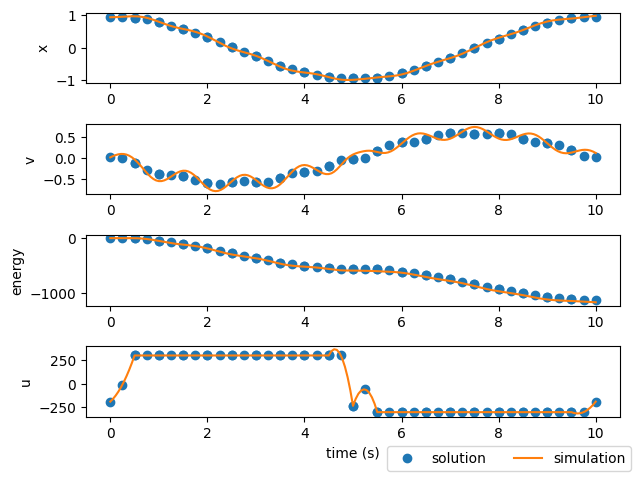

In [7]:
%matplotlib inline
states = ['x', 'v', 'energy','u']  # Change 'energy' to 'power'
fig, axes = plt.subplots(len(states), 1)
for i, state in enumerate(states):
    sol = axes[i].plot(t_sol, prob.get_val(f'traj.phase0.timeseries.{state}'), 'o')
    sim = axes[i].plot(t_sim, sim_out.get_val(f'traj.phase0.timeseries.{state}'), '-') 
    axes[i].set_ylabel(state)
axes[-1].set_xlabel('time (s)')
fig.legend((sol[0], sim[0]), ('solution', 'simulation'), loc='lower right', ncol=3)
plt.tight_layout()
plt.show()

In [8]:
energy_ts = prob.get_val(f'traj.phase0.timeseries.energy')
final_energy = energy_ts[-1]
avg_power = final_energy/t_interp_full[-1]
print(f'Avg power = {avg_power} W')

Avg power = [-112.32794512] W


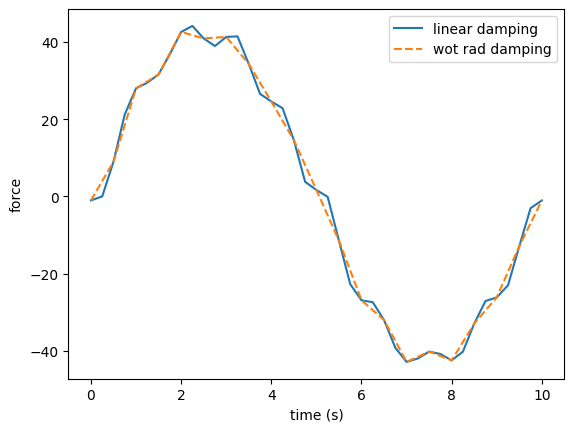

In [9]:
bem_data = xr.open_dataset('bem_wb_10.nc')

t_ts = prob.get_val('traj.phase0.timeseries.time')   # (Nt,)
t_ts = t_ts[:,0]
v_ts = prob.get_val('traj.phase0.timeseries.v')      # (Nt, 1) likely
t_interp = t_interp

c = 71
f_damper = -c * v_ts

t_round = np.round(t_ts, 14)  # helps if duplicates are floating-noise-close
_, idx = np.unique(t_round, return_index=True)
idx = np.sort(idx)
t_ts_new = t_ts[idx]
v_ts_new = v_ts[idx]

v_interp = np.interp(t_interp,t_ts_new,np.squeeze(v_ts_new))
v_fd_0 = td_to_fd(v_interp)
v_fd = v_fd_0[1:]
v_fd_real = complex_to_real(v_fd_0)

 # set all added mass to zero and radiation terms equal for linear test
bem_data['added_mass'][:,:,:] = 0
bem_data['radiation_damping'][:,:,:] = 71

rao_transfer_func_rad = np.squeeze(-bem_data['radiation_damping'] + 1j*bem_data['omega']*bem_data['added_mass'])
transfer_mat = mimo_transfer_mat(rao_transfer_func_rad)
time_matrix = time_mat_func(f1, nfreq)

rad_fd = np.dot(transfer_mat,v_fd_real) #  
radiation_damping_force_td = np.dot(time_matrix,rad_fd)
radiation_damping_force_td = np.append(radiation_damping_force_td, radiation_damping_force_td[0])
radiation_damping_force_td_interp = np.interp(t_ts,t_interp_full,np.squeeze(radiation_damping_force_td))

plt.figure()
plt.plot(t_ts,f_damper,label='linear damping',ls='-')
plt.plot(t_ts,radiation_damping_force_td_interp,label='wot rad damping',ls='--')
plt.xlabel('time (s)')
plt.ylabel('force')
plt.legend()